In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

from probjax.core import intervene, joint_sample, log_potential_fn
from probjax.core.custom_primitives.random_variable import rv_p
from probjax.stats import gamma, multivariate_normal, norm


In [2]:
def f(key):
    x = rv_p.bind(key,0., dist=norm, name="x")
    return x


f(jax.random.key(0))

Array(1.623, dtype=float32)

In [ ]:
joint_sample(f)(jax.random.key(0))

{'x': Array(1.623, dtype=float32)}

In [14]:
log_potential_fn(f)(x=1.)

Array(-1.419, dtype=float32)

In [7]:
type(jax.random.PRNGKey(0))

jaxlib.xla_extension.ArrayImpl

In [5]:
x = f(jrandom.PRNGKey(0))
sampler = joint_sample(conditional) # joint sample all RVs, intervention will be skipped
potential_fn = log_potential_fn(conditional, jrandom.PRNGKey(1))

NameError: name 'conditional' is not defined

In [ ]:
sampler(jrandom.PRNGKey(0))

{'z1': Array(1.119, dtype=float32), 'z2': Array(1.83, dtype=float32)}

In [ ]:
init_samples =  sampler(jrandom.PRNGKey(0))
flat_args,  in_tree = jax.tree_util.tree_flatten(init_samples)

In [2]:
mcmc = MCMC(GaussianKernel(), potential_fn, init_samples)

NameError: name 'GaussianKernel' is not defined

In [29]:
@jax.vmap
def mcmc_sampling(key):
    return mcmc.run(key,500)

samples = mcmc_sampling(jrandom.split(jrandom.PRNGKey(0), 1000))

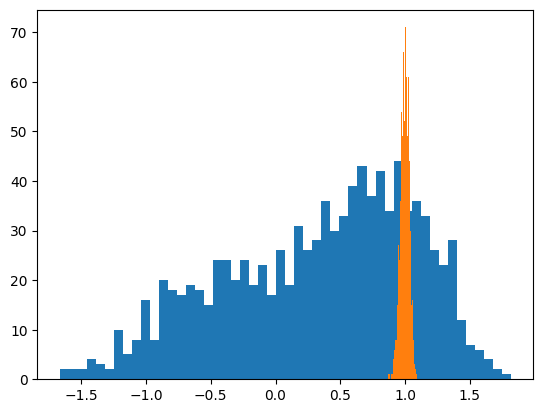

In [31]:
import matplotlib.pyplot as plt

_ = plt.hist(samples["z1"], bins=50)
_ = plt.hist(samples["z2"], bins=50)